<a href="https://colab.research.google.com/github/Janardan-thapaliya/LangGraph_workflows/blob/main/LangGraph_workflows.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Sequential Workflow**

In [ ]:
!pip install -q langgraph langchain langchain_openai python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.4/542.4 kB 17.0 MB/s eta 0:00:00


In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [ ]:
#define state
class BMIState(TypedDict):
    weight_kg: float
    height_m: float
    bmi: float
    category: str

In [ ]:
def calculate_bmi(state: BMIState) -> BMIState:
  weight = state['weight_kg']
  height = state['height_m']
  bmi = weight / (height ** 2)

  state['bmi'] = round(bmi, 2)
  return state

In [ ]:
def label_bmi(state: BMIState) -> BMIState:
  bmi = state['bmi']

  if bmi < 18.5:
    state['category'] = 'Underweight'
  elif 18.5 <= bmi < 25:
    state['category'] = 'Normal'
  elif 25 <= bmi < 30:
    state['category'] = 'Overweight'
  else:
    state['category'] = 'Obese'

  return state

•	The nodes will refer to a python function within graph.add_node(‘func’, func)

•	The function needs to have state as parameter/input and output becomes state as well  def func(state: State) -> State:

•	The code inside the function will extract datapoint from the State  data = state[‘data_defined_in_state’]

•	After the function is done, the value in state that results from the usage of function is updated in the state  state[‘result’] = result

•	At the end, the state is returned  return state


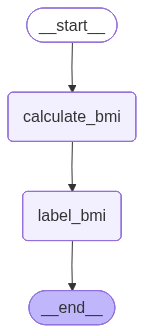

In [ ]:
#define graph
graph = StateGraph(BMIState)

#add nodes to graph
graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('label_bmi', label_bmi)

#add edges to graph
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'label_bmi')
graph.add_edge('label_bmi', END)

#compile the graph
g = graph.compile()
g


•	The execution of the graph consists of taking value of the initial state, invoking the graph to do certain task, then updating the state to get final completed state

In [ ]:
#execute the graph
initial_state = {'weight_kg': 71, 'height_m': 1.71}

final_state = g.invoke(initial_state)

print(final_state)

{'weight_kg': 71, 'height_m': 1.71, 'bmi': 24.28, 'category': 'Normal'}


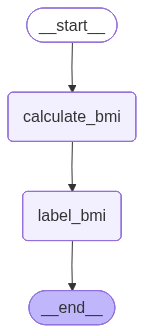

In [ ]:
from IPython.display import Image
Image(g.get_graph().draw_mermaid_png())

**LLM Workflow**

The sequence is to start --> run node llm_qa (which takes question q from state, sends to LLM for generation, and write back answer a to the state) --> End

In [ ]:
!pip install -q python-dotenv

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_openai import ChatOpenAI

In [ ]:
import os
from dotenv import load_dotenv

# Load the .env file from the current directory
load_dotenv()

True

In [ ]:
model = ChatOpenAI()

In [ ]:
#state

class LLMState(TypedDict):
  question: str
  answer: str

In [ ]:
#Create function for the node
def llm_qa(state: LLMState) -> LLMState:
  #extract question from state
  question = state['question']

  #form prompt using that question
  prompt = f"Answer the following question: {question}"

  #send prompt to LLM
  answer = model.invoke(prompt).content #answer is inside the content attribute, the models returns several other data points which are not needed here

  #update the answer in the state
  state['answer'] = answer

  return state

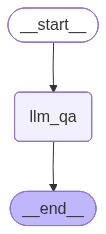

In [ ]:
#create graph
graph = StateGraph(LLMState)

#add nodes
graph.add_node('llm_qa', llm_qa)

#add edges
graph.add_edge(START, 'llm_qa')
graph.add_edge('llm_qa', END)

#compile
g = graph.compile()
g

In [ ]:
#Execute graph
#Initial state
initial_state = {'question': 'Why do humans have the tendency to self-sabotage?'}

#Final state
final_state = g.invoke(initial_state)

#Print state to check
print(final_state)

{'question': 'Why do humans have the tendency to self-sabotage?', 'answer': 'There are a variety of reasons why humans may have a tendency to self-sabotage. Some possible explanations include fear of failure or success, low self-esteem, lack of self-awareness, past trauma or conditioning, unhealthy coping mechanisms, negative self-talk, and a desire to maintain control in uncertain situations. Additionally, societal and cultural influences can also play a role in perpetuating self-sabotaging behaviors. Ultimately, understanding and addressing the root causes of self-sabotage can help individuals break free from harmful patterns and make positive changes in their lives.'}


In [ ]:
print(final_state['answer'])

There are a variety of reasons why humans may have a tendency to self-sabotage. Some possible explanations include fear of failure or success, low self-esteem, lack of self-awareness, past trauma or conditioning, unhealthy coping mechanisms, negative self-talk, and a desire to maintain control in uncertain situations. Additionally, societal and cultural influences can also play a role in perpetuating self-sabotaging behaviors. Ultimately, understanding and addressing the root causes of self-sabotage can help individuals break free from harmful patterns and make positive changes in their lives.


**Prompt Chaining**

Decomposing the task into series of components to make several LLM calls in order to solve the task is prompt chaining.

The task will be to create blog for given topic.

The workflow will start --> the topic will be retrieved from the state's topic and LLM will generate the outline which will be stored in state's outline --> this outline is parsed to LLM from the state to generate the blog which will be stored in the state's answer --> then it will end.

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_openai import ChatOpenAI

In [ ]:
import os
from dotenv import load_dotenv

load_dotenv()

True

In [ ]:
model = ChatOpenAI()

In [ ]:
#state

class BlogState(TypedDict):
  topic: str
  outline: str
  answer: str
  score: int

In [ ]:
#define node function get_outline
def get_outline(state: BlogState) -> BlogState:
  #get topic from state
  topic = state['topic']

  #create a prompt for LLM
  prompt = f"Generate a detailed outline for blog creation on the topic: {topic}"

  #send prompt to LLM
  outline = model.invoke(prompt).content

  #store the answer received from LLM to state's topic
  state['outline'] = outline

  return state

In [ ]:
#define node function gen_blog
def gen_blog(state: BlogState) -> BlogState:
  #get outline and topic from state
  topic = state['topic']
  outline = state['outline']

  #create a prompt for LLM to generate blog
  prompt = f"Generate the blog on the title - {topic} based on the outline: {outline}"

  #send prompt to LLM
  answer = model.invoke(prompt).content

  #store the answer in state's answer
  state['answer'] = answer

  return state

In [ ]:
#define function to rate blog generated based on outline in the scope of 10
def score_blog(state: BlogState) -> BlogState:
  #get outline and answer from state
  outline = state['outline']
  answer = state['answer']

  #create prompt for LLM to evaluate
  prompt = f"Rate in the scale of 10 - integer only response - the quality of this blog: {answer} based on the outlines: {outline}"

  #Pass prompt to LLM and get the score back
  score = int(model.invoke(prompt).content)

  #store the score in state
  state['score'] = score

  return state

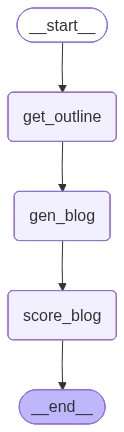

In [ ]:
#define graph
graph = StateGraph(BlogState)

#add nodes to graph
graph.add_node('get_outline', get_outline)
graph.add_node('gen_blog', gen_blog)
graph.add_node('score_blog', score_blog)

#add edges to graph
graph.add_edge(START, 'get_outline')
graph.add_edge('get_outline', 'gen_blog')
graph.add_edge('gen_blog', 'score_blog')
graph.add_edge('score_blog', END)

#compile graph
pc = graph.compile()
pc

In [ ]:
#Execute graph
#initial state
initial_state = {'topic': 'Usage of AI in educational resource generation'}

#final state
final_state = pc.invoke(initial_state)

#print final state
print(final_state)

{'topic': 'Usage of AI in educational resource generation', 'outline': 'I. Introduction\n    A. Explanation of AI \n    B. Definition of educational resource generation \n    C. Thesis statement: AI has revolutionized the way educational resources are created\n    \nII. Overview of AI in Education\n    A. Brief history of AI in education \n    B. Examples of AI technologies used in education \n    C. Benefits of using AI in education \n\nIII. Role of AI in Educational Resource Generation\n    A. Definition of educational resource generation \n    B. Explanation of how AI is used to generate educational resources \n    C. Examples of AI tools and platforms used for educational resource generation \n\nIV. Benefits of AI in Educational Resource Generation\n    A. Increased efficiency and productivity \n    B. Personalization and adaptive learning \n    C. Accessibility and inclusivity \n    D. Cost-effectiveness \n\nV. Challenges and Limitations of AI in Educational Resource Generation\n 

In [ ]:
print(final_state['outline'])

I. Introduction
    A. Explanation of AI 
    B. Definition of educational resource generation 
    C. Thesis statement: AI has revolutionized the way educational resources are created
    
II. Overview of AI in Education
    A. Brief history of AI in education 
    B. Examples of AI technologies used in education 
    C. Benefits of using AI in education 

III. Role of AI in Educational Resource Generation
    A. Definition of educational resource generation 
    B. Explanation of how AI is used to generate educational resources 
    C. Examples of AI tools and platforms used for educational resource generation 

IV. Benefits of AI in Educational Resource Generation
    A. Increased efficiency and productivity 
    B. Personalization and adaptive learning 
    C. Accessibility and inclusivity 
    D. Cost-effectiveness 

V. Challenges and Limitations of AI in Educational Resource Generation
    A. Data privacy and security concerns 
    B. Bias and fairness issues 
    C. Lack of huma

In [ ]:
print(final_state['answer'])

In today's digital age, Artificial Intelligence (AI) has become increasingly prevalent in various industries, including education. AI has revolutionized the way educational resources are created, making the process more efficient, personalized, and inclusive. This blog will delve into the usage of AI in educational resource generation and explore its benefits, challenges, and future implications.

AI, in simple terms, refers to the simulation of human intelligence processes by machines. Educational resource generation, on the other hand, involves the creation of materials and tools that support teaching and learning. With the help of AI, educators can now develop innovative and engaging resources for students that cater to their individual needs and preferences.

The overview of AI in education will showcase a brief history of AI in the educational sector, highlighting key milestones and advancements. Examples of AI technologies used in education, such as intelligent tutoring systems a

In [ ]:
print(final_state['score'])

9


**Parallel workflows in LangGraph**

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [ ]:
#Define state
class BatsmanState(TypedDict):
  runs: int
  balls: int
  fours: int
  sixes: int

  sr: float #Strike rate
  bpb: float #Balls per boundary
  boundary_percent: float #Boundary percentage

  summary: str

In [ ]:
#define function to calculate strike rate
def calc_sr(state: BatsmanState) -> BatsmanState:
  #get runs and balls from state
  runs = state['runs']
  balls = state['balls']

  #calculate strike rate
  sr = (round(runs / balls))*100

  #update sr in state
  state['sr'] = sr

  return state

In [ ]:
#define function to calculate balls per boundary
def calc_bpb(state: BatsmanState) -> BatsmanState:
  #get balls, and boundaries from state
  balls = state['balls']
  fours = state['fours']
  sixes = state['sixes']

  #calculate bpb
  bpb = round(balls / (fours + sixes))

  #update bpb in state
  state['bpb'] = bpb

  return state

In [ ]:
#define function to calculate boundary percentage
def calc_boundary_percent(state: BatsmanState) -> BatsmanState:
  #get boundaries and runs
  fours = state['fours']
  sixes = state['sixes']
  runs = state['runs']

  #calculate boundary percentage
  boundary_percent = round((((fours * 4) + (sixes * 6)) / runs) * 100)

  #update boundary percentage in state
  state['boundary_percent'] = boundary_percent

  return state

In [ ]:
#define function to summarize
def summarize(state: BatsmanState) -> BatsmanState:
  #get sr, bpb, boundary_percent from state
  sr = state['sr']
  bpb = state['bpb']
  boundary_percent = state['boundary_percent']

  #Format the summary
  summary = f"Strike rate: {sr}\nBalls per boundary: {bpb}\nBoundary percentage: {boundary_percent}"

  #update to state
  state['summary'] = summary

  return state

In [ ]:
#Define graph
graph = StateGraph(BatsmanState)

#Add nodes to graph
graph.add_node('calc_sr', calc_sr)
graph.add_node('calc_bpb', calc_bpb)
graph.add_node('calc_boundary_percent', calc_boundary_percent)
graph.add_node('summarize', summarize)

**Edges is where the parallel workflow differs from sequential one.**

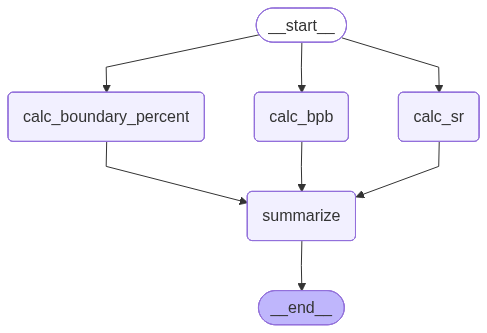

In [ ]:
#Add edges to graph
graph.add_edge(START, 'calc_sr')
graph.add_edge(START, 'calc_bpb')
graph.add_edge(START, 'calc_boundary_percent')
graph.add_edge('calc_sr', 'summarize')
graph.add_edge('calc_bpb', 'summarize')
graph.add_edge('calc_boundary_percent', 'summarize')
graph.add_edge('summarize', END)

#Compile the graph
g = graph.compile()
g

In [ ]:
#Execute the workflow
#Initial state
initial_state = {
    'runs': 100,
    'balls': 50,
    'fours': 6,
    'sixes': 4
}

#final state
final_state = g.invoke(initial_state)

#print state
print(final_state)

InvalidUpdateError: At key 'runs': Can receive only one value per step. Use an Annotated key to handle multiple values.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_CONCURRENT_GRAPH_UPDATE

**This error illustrates that parallel workflow deviates from sequential workflow in that several components/nodes are trying to simultaneously return the full State. This results in conflict since Langgraph is not sure whose data is to be considered correct (for the data that are read or written in all or multiple nodes).**

The solution is to update only the partial component which the node is handling. State is dict so we can update it as key-value pair like {'sr': sr}

In [ ]:
#define function to calculate strike rate
def calc_sr(state: BatsmanState) -> BatsmanState:
  #get runs and balls from state
  runs = state['runs']
  balls = state['balls']

  #calculate strike rate
  sr = (round(runs / balls))*100

  #Return partial state update
  return {'sr': sr}

In [ ]:
#define function to calculate balls per boundary
def calc_bpb(state: BatsmanState) -> BatsmanState:
  #get balls, and boundaries from state
  balls = state['balls']
  fours = state['fours']
  sixes = state['sixes']

  #calculate bpb
  bpb = round(balls / (fours + sixes))

  #Return partial state update
  return {'bpb': bpb}

In [ ]:
#define function to calculate boundary percentage
def calc_boundary_percent(state: BatsmanState) -> BatsmanState:
  #get boundaries and runs
  fours = state['fours']
  sixes = state['sixes']
  runs = state['runs']

  #calculate boundary percentage
  boundary_percent = round((((fours * 4) + (sixes * 6)) / runs) * 100)

  #Return partial state update
  return {'boundary_percent': boundary_percent}

In [ ]:
#define function to summarize
def summarize(state: BatsmanState) -> BatsmanState:
  #get sr, bpb, boundary_percent from state
  sr = state['sr']
  bpb = state['bpb']
  boundary_percent = state['boundary_percent']

  #Format the summary
  summary = f"Strike rate: {sr}\nBalls per boundary: {bpb}\nBoundary percentage: {boundary_percent}"

  #Return partial state update
  return {'summary': summary}

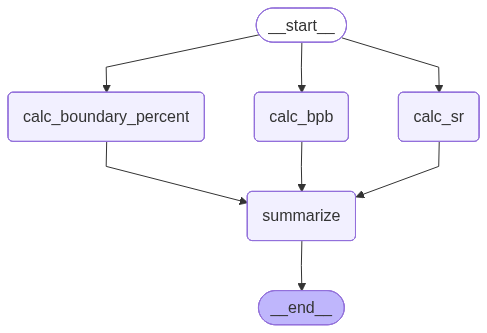

In [ ]:
#Define graph
graph = StateGraph(BatsmanState)

#Add nodes to graph
graph.add_node('calc_sr', calc_sr)
graph.add_node('calc_bpb', calc_bpb)
graph.add_node('calc_boundary_percent', calc_boundary_percent)
graph.add_node('summarize', summarize)

#Add edges to graph
graph.add_edge(START, 'calc_sr')
graph.add_edge(START, 'calc_bpb')
graph.add_edge(START, 'calc_boundary_percent')
graph.add_edge('calc_sr', 'summarize')
graph.add_edge('calc_bpb', 'summarize')
graph.add_edge('calc_boundary_percent', 'summarize')
graph.add_edge('summarize', END)

#Compile the graph
g = graph.compile()
g

In [ ]:
#Execute the workflow
#Initial state
initial_state = {
    'runs': 100,
    'balls': 50,
    'fours': 6,
    'sixes': 4
}

#final state
final_state = g.invoke(initial_state)

#print state
print(final_state)

{'runs': 100, 'balls': 50, 'fours': 6, 'sixes': 4, 'sr': 200, 'bpb': 5, 'boundary_percent': 48, 'summary': 'Strike rate: 200\nBalls per boundary: 5\nBoundary percentage: 48'}


In [ ]:
print(final_state['summary'])

Strike rate: 200
Balls per boundary: 5
Boundary percentage: 48


**LLM based parallel workflow**

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field
import operator

In [ ]:
import os
from dotenv import load_dotenv

load_dotenv()

True

In [ ]:
model = ChatOpenAI(model='gpt-4o-mini')   #For structured output

In [ ]:
#Schema for structured output: Score needs to be integer, the model can output Seven, 7, 7 as string etc

class EvaluationSchema(BaseModel):
  score: int = Field(description='Score out of 10', ge=0, le=10) #Contraints that will limit the score greater than or equal to 0 and less than or equal to 10
  feedback: str = Field(description='Detailed feedback for the essay') #Field is for LLM's reference

In [ ]:
#Pass the schema to model.with_strctured_output to validate the result with schema defined
structured_model = model.with_structured_output(EvaluationSchema)

In [ ]:
#State

class EssayState(TypedDict):

  essay_text: str  #Input Essay
  CoT_feedback: str #Clarity of thought
  DoA_feedback: str  #Depth of Analysis
  language_feedback: str #Language clarity

  final_feedback: str   #Summary of feedbacks

  #Reducer funtion which adds several items inside the list - operator.add
  individual_scores: Annotated[list[int], operator.add]   #Each LLM sends their score as a single item list which is added here - Eliminating the risk of overwriting by each node
  avg_score: float  #Average score calculated from all 3 feedbacks

In [ ]:
#Define function for evaluating language
def evaluate_language(state: EssayState) -> EssayState:
  #get essay_text from the state
  essay_text = state['essay_text']

  #Create prompt for evaluating language clarity
  prompt = f"Evaluate the language clarity of the following essay and provide a feedback and assign a score out of 10: \n {essay_text}"

  #Pass the prompt and invoke the LLM
  evaluation = structured_model.invoke(prompt)

  #Extract the language_feedback and list containing score and partially update the state
  language_feedback = evaluation.feedback
  individual_scores = [evaluation.score]

  #Update the state
  return {'language_feedback': language_feedback, 'individual_scores': individual_scores}

In [ ]:
#Define function for evaluating depth of analysis
def evaluate_depth_of_analysis(state: EssayState) -> EssayState:
  #get essay_text from the state
  essay_text = state['essay_text']

  #Create prompt for evaluating depth of analysis
  prompt = f"Evaluate the depth of analysis of the following essay and provide a feedback and assign a score out of 10: \n {essay_text}"

  #Pass the prompt and invoke the LLM
  evaluation = structured_model.invoke(prompt)

  #Extract the DoA_feedback and list containing score and partially update the state
  DoA_feedback = evaluation.feedback
  individual_scores = state['individual_scores'] + [evaluation.score]

  #update state
  return {'DoA_feedback': DoA_feedback, 'individual_scores': individual_scores}

In [ ]:
#Define function for evaluating clarity of thought
def evaluate_clarity_of_thought(state: EssayState) -> EssayState:
  #get essay_text from the state
  essay_text = state['essay_text']

  #Create prompt for evaluating clarity of thought
  prompt = f"Evaluate the clarity of thought of the following essay and provide a feedback and assign a score out of 10: \n {essay_text}"

  #Pass the prompt and invoke the LLM
  evaluation = structured_model.invoke(prompt)

  #Extract
  CoT_feedback = evaluation.feedback
  individual_scores = state['individual_scores'] + [evaluation.score]

  #update state
  return {'CoT_feedback': CoT_feedback, 'individual_scores': individual_scores}

In [ ]:
#Define function for summarizing all feedbacks from evaluations
def final_evaluation(state: EssayState) -> EssayState:
  #get the feedbacks of all 3 LLMs from the state to create a summary
  language_feedback = state['language_feedback']
  DoA_feedback = state['DoA_feedback']
  CoT_feedback = state['CoT_feedback']

  #get the score from the state
  individual_scores = state['individual_scores']

  #Create prompt for summrizing these feedbacks
  prompt = f"Based on the following feedbacks, create a summarized feedback \n language feedback: {language_feedback} \n depth of analysis feedback: {DoA_feedback} \n clarity of thought feedback: {CoT_feedback}"

  #Invoke LLM to create summary
  final_feedback = model.invoke(prompt).content

  #Calculate average
  avg_score = sum(individual_scores) / len(individual_scores)

  #update state
  return {'final_feedback': final_feedback, 'avg_score': avg_score}

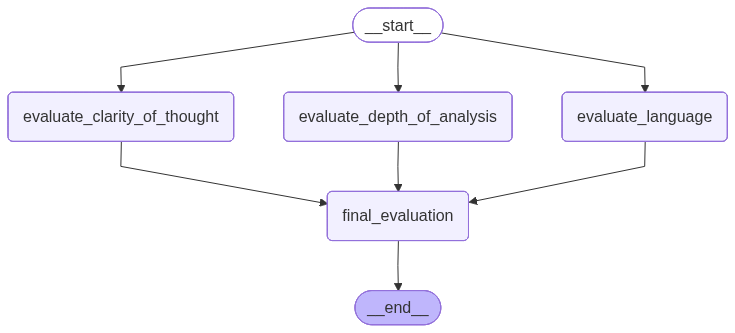

In [ ]:
#Create graph
graph = StateGraph(EssayState)

#Add nodes to graph
graph.add_node('evaluate_language', evaluate_language)
graph.add_node('evaluate_depth_of_analysis', evaluate_depth_of_analysis)
graph.add_node('evaluate_clarity_of_thought', evaluate_clarity_of_thought)
graph.add_node('final_evaluation', final_evaluation)

#Add edges to graph
graph.add_edge(START, 'evaluate_language')
graph.add_edge(START, 'evaluate_depth_of_analysis')
graph.add_edge(START, 'evaluate_clarity_of_thought')
graph.add_edge('evaluate_language', 'final_evaluation')
graph.add_edge('evaluate_depth_of_analysis', 'final_evaluation')
graph.add_edge('evaluate_clarity_of_thought', 'final_evaluation')
graph.add_edge('final_evaluation', END)

#Compile graph
g = graph.compile()
g

In [ ]:
essay = """
In today's digital age, Artificial Intelligence (AI) has become increasingly prevalent in various industries, including education. AI has revolutionized the way educational resources are created, making the process more efficient, personalized, and inclusive. This blog will delve into the usage of AI in educational resource generation and explore its benefits, challenges, and future implications.

AI, in simple terms, refers to the simulation of human intelligence processes by machines. Educational resource generation, on the other hand, involves the creation of materials and tools that support teaching and learning. With the help of AI, educators can now develop innovative and engaging resources for students that cater to their individual needs and preferences.

The overview of AI in education will showcase a brief history of AI in the educational sector, highlighting key milestones and advancements. Examples of AI technologies used in education, such as intelligent tutoring systems and virtual reality platforms, will be discussed, along with the benefits of using AI in education, such as improved student outcomes and enhanced learning experiences.

The role of AI in educational resource generation will be explored in depth, focusing on how AI is utilized to create and distribute educational materials. Various AI tools and platforms used for educational resource generation, such as content creation algorithms and data analytics software, will be highlighted to showcase the diverse ways in which AI is transforming the field of education.

The benefits of AI in educational resource generation are manifold, ranging from increased efficiency and productivity to personalized and adaptive learning experiences. AI also promotes accessibility and inclusivity by providing tailored resources for students with diverse learning needs, all while remaining cost-effective for educational institutions.

However, despite these advantages, there are challenges and limitations associated with the use of AI in educational resource generation. Concerns around data privacy and security, bias and fairness issues, and the lack of human interaction and personalized feedback are important factors to consider when implementing AI in education.

Case studies will be presented to illustrate real-world examples of schools or institutions using AI for educational resource generation, showcasing the success stories and outcomes of these initiatives. Lessons learned from these case studies will provide valuable insights for educators and policymakers looking to leverage AI technologies in the educational setting.

Looking towards the future, the blog will explore emerging trends and technologies in AI for educational resource generation and discuss the potential impact on the education industry. Recommendations for educators and policymakers on how to embrace AI in education will also be provided, along with a call to action for them to explore the benefits of AI technologies.

In conclusion, the importance of embracing AI in educational resource generation cannot be overstated. AI has the potential to transform the way educational materials are created and accessed, offering new opportunities for personalized learning and inclusive education. It is essential for educators to stay informed and proactive in exploring AI technologies to enhance the learning experiences of their students. With careful consideration of the benefits, challenges, and future implications of AI in education, the possibilities for innovative educational resource generation are limitless.
"""

In [ ]:
#Execute the graph
#initial state
initial_state = {
    'essay_text': essay
}
#final state
final_state = g.invoke(initial_state)

#print state
print(final_state)

{'essay_text': "\nIn today's digital age, Artificial Intelligence (AI) has become increasingly prevalent in various industries, including education. AI has revolutionized the way educational resources are created, making the process more efficient, personalized, and inclusive. This blog will delve into the usage of AI in educational resource generation and explore its benefits, challenges, and future implications.\n\nAI, in simple terms, refers to the simulation of human intelligence processes by machines. Educational resource generation, on the other hand, involves the creation of materials and tools that support teaching and learning. With the help of AI, educators can now develop innovative and engaging resources for students that cater to their individual needs and preferences.\n\nThe overview of AI in education will showcase a brief history of AI in the educational sector, highlighting key milestones and advancements. Examples of AI technologies used in education, such as intellig

In [ ]:
print(final_state['final_feedback'])

**Summarized Feedback:**

The essay provides a clear and coherent overview of AI in educational resource generation, showcasing a well-organized structure that transitions smoothly from introductions to applications, benefits, challenges, and future implications. The language is generally accessible, although some repetitive phrases detract from clarity, and transitions between sections could be streamlined.

While the analysis offers a solid understanding of the topic, it would benefit from deeper exploration of specific challenges, such as data privacy and bias, including concrete examples and detailed discussions on potential solutions. Mentioned case studies are not elaborated upon, which limits the depth of the argument. The conclusion effectively summarizes the significance of AI but could include specific recommendations for educators and policymakers.

Overall, the essay successfully communicates its main ideas and demonstrates a good grasp of the subject. With minor adjustment

In [ ]:
print(final_state['avg_score'])

7.666666666666667


In [ ]:
print(final_state['CoT_feedback'])

The essay presents a well-structured overview of the impact of AI in educational resource generation, effectively outlining its benefits, challenges, and future implications. The clarity of thought is commendable, as the author systematically addresses various aspects, including a definition of AI, its applications in education, and potential concerns regarding implementation. 

Strengths include the logical progression from introductory concepts to more detailed discussions on AI's usage, along with a clear indication of the structure and intent at the onset. The use of examples and case studies promises to enhance the practical understanding of the topic, although they were mentioned rather than elaborated on within the text.

However, the essay could benefit from a more in-depth exploration of certain challenges associated with AI, particularly in relation to specific examples or data to strengthen its arguments. Additionally, while the writing is generally clear, there are moments 

In [ ]:
print(final_state['DoA_feedback'])

The essay provides a thorough overview of the role of AI in educational resource generation, touching on its benefits, challenges, and future implications. It presents a clear structure, moving from a definition of AI to its applications in education, benefits, challenges, and real-world case studies, which shows a logical depth of analysis. However, while it covers a wide range of topics, the analysis could benefit from more in-depth exploration of each point. For instance, the discussion on challenges like data privacy and bias is mentioned but lacks concrete examples or detailed analysis on how these issues can be addressed. Case studies are suggested but not included; actual examples would greatly enhance the argument. Additionally, while the conclusion summarizes the importance of AI, it could further explore specific recommendations or strategic actions for educators and policymakers. Overall, the essay demonstrates a solid understanding of the topic but would benefit from a deep

In [ ]:
print(final_state['language_feedback'])

Overall, the essay displays good clarity and coherence. The structure is well-organized, moving from the introduction of AI in education to specific applications, benefits, challenges, and future implications. The language is generally accessible, using straightforward terminology to explain complex concepts. However, there are instances of repetitive phrases, particularly around the benefits and applications of AI, which could be streamlined for greater clarity. Adding a few more examples or specific data points could enhance the depth of discussion. Also, transitions between sections could be improved to ensure a smoother flow of ideas. Overall, it's a solid piece with minor areas for improvement.


In [ ]:
print(final_state['individual_scores'])

[8, 7, 8]


**Conditional Workflow**

In [ ]:
#Task is to calculate Quadratic equaltion: The conditions are if discriminant d>0 then, 2 real roots, if d=0, repeated equal roots and if d<0, no real roots

#imports
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [ ]:
#State

class QuadState(TypedDict):
  a: int
  b: int
  c: int

  equation: str
  discriminant: float
  result: str

In [ ]:
#Create function to show equation
def show_equation(state: QuadState) -> QuadState:
  #get variables from the state
  a = state['a']
  b = state['b']
  c = state['c']

  #form equation in string
  equation = f"{a}x^2 + {b}x + {c}"

  #update state
  return {'equation': equation}

In [ ]:
#create funtion to calculate discriminant
def calculate_discriminant(state: QuadState) -> QuadState:
  #get variables from the state
  a = state['a']
  b = state['b']
  c = state['c']

  #calculate discriminant
  discriminant = (b ** 2) - (4 * a * c)

  #update state
  return {'discriminant': discriminant}

In [ ]:
#Create function to calculte real roots
def real_roots(state: QuadState) -> QuadState:
  #get variables from the state
  a = state['a']
  b = state['b']
  c = state['c']
  discriminant = state['discriminant']

  #calculate real roots
  root1 = (-b + (discriminant ** 0.5)) / (2 * a)
  root2 = (-b - (discriminant ** 0.5)) / (2 * a)

  #write these roots into the result and return to state
  result = f"The roots are {root1} and {root2}"

  #update state
  return {'result': result}

In [ ]:
#Create function to calculate repeated roots
def repeated_roots(state: QuadState) -> QuadState:
  #get variables from the state
  a = state['a']
  b = state['b']
  c = state['c']
  discriminant = state['discriminant']

  #calculate repeated roots
  root = (-b + (discriminant ** 0.5)) / (2 * a)

  #Write root into result
  result = f"The repeating root is {root}"

  #update state
  return {'result': result}

In [ ]:
#Create function to show no real roots
def no_real_roots(state: QuadState) -> QuadState:
  #set the result to show no real roots
  result = "No real roots"

  #update state
  return {'result': result}


In [ ]:
#Create standalone function which is not part of any node to check condition: routing function
def check_condition(state: QuadState) -> Literal["real_roots", "repeated_roots", "no_real_roots"]:

  #get discriminant from the state
  discriminant = state['discriminant']

  #check condition
  if discriminant > 0:
    return "real_roots"

  elif discriminant == 0:
    return "repeated_roots"

  else:
    return "no_real_roots"


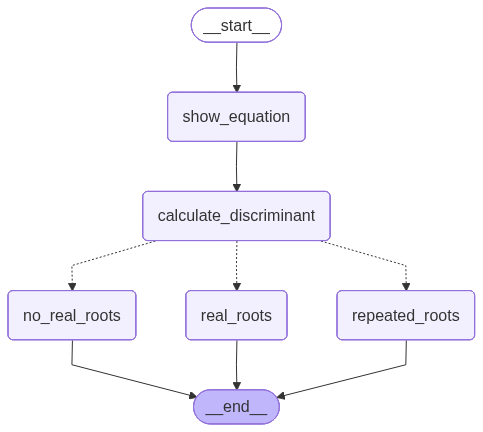

In [ ]:
#Build graph
graph = StateGraph(QuadState)

#Add nodes to graph
graph.add_node('show_equation', show_equation)
graph.add_node('calculate_discriminant', calculate_discriminant)
graph.add_node('real_roots', real_roots)
graph.add_node('repeated_roots', repeated_roots)
graph.add_node('no_real_roots', no_real_roots)

#Add edges to graph
graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'calculate_discriminant')

#Conditional edge
graph.add_conditional_edges('calculate_discriminant', check_condition) #check_condition will replace the name of those nodes according to condition triggered
graph.add_edge('real_roots', END)
graph.add_edge('repeated_roots', END)
graph.add_edge('no_real_roots', END)

#Compile graph
g = graph.compile()
g

In [ ]:
#Executing the graph
#initial state
initial_state = {
    'a': 2,
    'b': 4,
    'c': 2
}

#final state
final_state = g.invoke(initial_state)

#print state
print(final_state)

{'a': 2, 'b': 4, 'c': 2, 'equation': '2x^2 + 4x + 2', 'discriminant': 0, 'result': 'The repeating root is -1.0'}


**LLM Based conditional workflow**

Review handling workflow

Get review as Input --> Find sentiment of the review using LLM

If positive (+ve) --> Reply thanks and appreciation message

If negative (-ve) --> Run diagnosis --> Use diagnosis result to create suitable reply

Diagnosis will have structured: issue_type, tone, urgency

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

In [ ]:
load_dotenv()

True

In [ ]:
model = ChatOpenAI(model='gpt-4o-mini')

In [ ]:
#Schema for structured output
class SentimentSchema(BaseModel):
  sentiment: Literal['positive', 'negative'] = Field(description='Sentiment of the review')

In [ ]:
#Schema for diagnosis
class DiagnosisSchema(BaseModel):
  issue_type: Literal['Bug', 'Performance', 'UX', 'Support', 'Other'] = Field(description='The category of issue mentioned in review.')
  tone: Literal['Angry', 'Calm', 'Disappointed', 'Frustrated'] = Field(description='The emotional tone expressed by user in their review.')
  urgency: Literal['High', 'Medium', 'Low'] = Field(description='How urgent or critical the issue appears to be.')

In [ ]:
structured_model = model.with_structured_output(SentimentSchema)

In [ ]:
diagnosis_model = model.with_structured_output(DiagnosisSchema)

In [ ]:
prompt = 'What is the sentiment of the following review - The software is okay.'
structured_model.invoke(prompt).sentiment

'negative'

In [ ]:
#State

class ReviewState(TypedDict):
  review: str
  sentiment: Literal['positive', 'negative']
  diagnosis: dict

  reply: str

In [ ]:
#Create function to get sentiment of the review

def find_sentiment(state: ReviewState) -> ReviewState:
  #get the review from state
  review = state['review']

  #create prompt to get sentiment from LLM
  prompt = f"What is the sentiment of the following review - {review}"

  #call LLM to provide structured sentiment
  sentiment = structured_model.invoke(prompt).sentiment

  #update state
  return {'sentiment': sentiment}

In [ ]:
# Create conditional function to determine flow after sentiment

def check_condition(state: ReviewState) -> Literal["reply_positive", "run_diagnosis"]:
  #get sentiment from state
  sentiment = state['sentiment']

  #check the conditional flow to make decision
  if sentiment == 'positive':
    return 'reply_positive'
  else:
    return 'run_diagnosis'

In [ ]:
#create node funtion for reply_positive

def reply_positive(state: ReviewState) -> ReviewState:

  #Get review from state
  review = state['review']

  #Create a prompt to make LLM write a warm response
  prompt = f"Write a warm thank-you message in response to this review: \n {review} \n Also, kindly ask the user to leave feedback on our website."

  #invoke the prompt
  reply = model.invoke(prompt).content

  #return reply to state
  return {'reply': reply}

In [ ]:
#Create node function for run_diagnosis

def run_diagnosis(state: ReviewState) -> ReviewState:

  #Get review from state to run diagnosis LLM
  review = state['review']

  #Create prompt to run diagnosis and get structured output from LLM
  prompt = f"Run diagnosis on the following review: \n {review}"
  diagnosis = diagnosis_model.invoke(prompt)

  #Convert result into dict to match diagnosis type
  response = diagnosis.model_dump()

  #update state
  return {'diagnosis': response}


In [ ]:
#Create node function for negative_reply

def reply_negative(state: ReviewState) -> ReviewState:
  #get daignosis from state
  diagnosis = state['diagnosis']

  #Access each type of data point from diagnosis
  issue_type = diagnosis['issue_type']
  tone = diagnosis['tone']
  urgency = diagnosis['urgency']

  #Create a prompt to pass these types to LLM to create appropriate response
  prompt = f""" You are a customer service agent.
  The user had a '{issue_type}' issue, sounded '{tone}', and marked urgecy as '{urgency}'.
  Write an empathetically appealing and helpful resolution response to this user.
  """

  #Call model to generate response
  reply = model.invoke(prompt).content

  #update state
  return {'reply': reply}

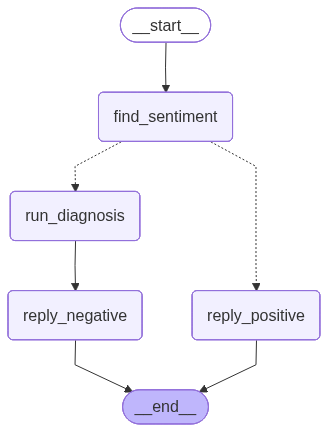

In [ ]:
#Build graph
graph = StateGraph(ReviewState)

#Add node to graph
graph.add_node('find_sentiment', find_sentiment)
graph.add_node('reply_positive', reply_positive)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('reply_negative', reply_negative)

#Add edge to graph
graph.add_edge(START, 'find_sentiment')

graph.add_conditional_edges('find_sentiment', check_condition)
graph.add_edge('reply_positive', END)
graph.add_edge('run_diagnosis', 'reply_negative')
graph.add_edge('reply_negative', END)

#Compile graph
g = graph.compile()
g

In [ ]:
#Execute the graph

#Initial state
initial_state = {
    'review': 'The software is really good. Kudos to the design team. I have been using for a month and the UI is incredibly clean and intuitive. I am looking forward to the great things the company will do.'
}

#Final state
final_state = g.invoke(initial_state)

#print state
print(final_state)

{'review': 'The software is really good. Kudos to the design team. I have been using for a month and the UI is incredibly clean and intuitive. I am looking forward to the great things the company will do.', 'sentiment': 'positive', 'reply': "Subject: Thank You for Your Wonderful Review!\n\nDear [User's Name],\n\nThank you so much for your kind words! We're thrilled to hear that you’re enjoying our software and that our design team's efforts have made a positive impact on your experience. Your feedback about the clean and intuitive UI truly means a lot to us. \n\nWe’re excited about the future and all the great things we have in store, and your support motivates us to keep pushing forward. If you have a moment, we would greatly appreciate it if you could share your thoughts on our website. Your feedback helps us improve and reach even more users like you!\n\nThank you once again for your kind support. We’re looking forward to continuing this journey with you!\n\nWarm regards,\n\n[Your N

In [ ]:
print(final_state['reply'])

Subject: Thank You for Your Wonderful Review!

Dear [User's Name],

Thank you so much for your kind words! We're thrilled to hear that you’re enjoying our software and that our design team's efforts have made a positive impact on your experience. Your feedback about the clean and intuitive UI truly means a lot to us. 

We’re excited about the future and all the great things we have in store, and your support motivates us to keep pushing forward. If you have a moment, we would greatly appreciate it if you could share your thoughts on our website. Your feedback helps us improve and reach even more users like you!

Thank you once again for your kind support. We’re looking forward to continuing this journey with you!

Warm regards,

[Your Name]  
[Your Position]  
[Your Company]


In [ ]:
#Execute the graph

#Initial state
initial_state = {
    'review': 'I am pissed off. I have been trying to login to this shitty app for over an hour and no luck. This kind of authentication bug is unacceptable, I do not have access to basic functionality.'
}

#Final state
final_state = g.invoke(initial_state)

#print state
print(final_state)

{'review': 'I am pissed off. I have been trying to login to this shitty app for over an hour and no luck. This kind of authentication bug is unacceptable, I do not have access to basic functionality.', 'sentiment': 'negative', 'diagnosis': {'issue_type': 'Bug', 'tone': 'Angry', 'urgency': 'High'}, 'reply': "Subject: We're Here to Help with Your Bug Issue\n\nDear [User's Name],\n\nThank you for reaching out to us and sharing your concerns. I understand how frustrating it can be to encounter a bug, especially when you’re relying on our service. I want you to know that your issue is important to us, and I’m here to help resolve it as quickly as possible.\n\nTo better assist you, could you please provide me with a few more details about the bug you're experiencing? Any specific steps you took before it occurred, or any error messages you’ve seen, will be incredibly helpful in pinpointing the issue.\n\nIn the meantime, I recommend trying to restart the application or device, as this sometim

In [ ]:
print(final_state['reply'])

Subject: We're Here to Help with Your Bug Issue

Dear [User's Name],

Thank you for reaching out to us and sharing your concerns. I understand how frustrating it can be to encounter a bug, especially when you’re relying on our service. I want you to know that your issue is important to us, and I’m here to help resolve it as quickly as possible.

To better assist you, could you please provide me with a few more details about the bug you're experiencing? Any specific steps you took before it occurred, or any error messages you’ve seen, will be incredibly helpful in pinpointing the issue.

In the meantime, I recommend trying to restart the application or device, as this sometimes resolves unexpected glitches. However, I understand if that’s not a solution or doesn’t apply to your situation.

Your satisfaction is our top priority, and I assure you that we're committed to resolving this issue for you promptly. Please reply to this email at your earliest convenience, and I'll do everything I

**Iterative Workflow**

The task is to automate funny and original tweet for X platform.

The topic will be provided.

The generator will use it to generate tweet --> passed to evaluator to check quality.

Condition will be checked if the quality is good enough --> If good, used for posting so END

If bad, it will be iteratively Optimized until it passes the quality check.

In [ ]:
!pip install -q langgraph langchain langchain_openai langchain_core python-dotenv

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from pydantic import BaseModel, Field
import operator

In [ ]:
import os
from dotenv import load_dotenv

load_dotenv()

True

In [ ]:
#Choose suitable specific models for each task

generator_llm = ChatOpenAI(model='gpt-4o-mini')
evaluator_llm = ChatOpenAI(model='gpt-4o')
optimizer_llm = ChatOpenAI(model='gpt-4o-mini')

In [ ]:
#Schema for Evaluator LLM to generate feedback and evaluation
class EvaluationSchema(BaseModel):
  evaluation: Literal['approved', 'needs_improvement'] = Field(description='Final Evaluation of the tweet')
  evaluator_feedback: str = Field(description='Feedback of the evaluator to improve the tweet, targeting areas where it failed.')

In [ ]:
structured_evaluator_LLM = evaluator_llm.with_structured_output(EvaluationSchema)

In [ ]:
#State

class TweetState(TypedDict):
  topic: str
  tweet: str
  evaluation: Literal['approved', 'needs_improvement']
  evaluator_feedback: str
  iteration: int
  max_iteration: int

  tweet_history: Annotated[list[str], operator.add, Field(description='History of tweets')]
  feedback_history: Annotated[list[str], operator.add, Field(description='History of feedback')]

In [ ]:
#Create function to generate tweet
def generate_tweet(state: TweetState) -> TweetState:
  #get topic from state and iteration
  topic = state['topic']
  iteration = state['iteration']

  #Create prompt for Generator LLM
  prompt = [
      SystemMessage(content="You are a funny and clever Twitter/X influencer."),
      HumanMessage(content=f"""
      Write a short, hilarious and original tweet about the topic: "{topic}"
      Rules:
      - DO NOT use question-answer format.
      - Max 280 characters.
      - Use observational humor, irony, sarcasm, lampoon, or cultural references.
      - Think in meme logic, punchlines, or relatable takes.
      - Use simple, day to day english.
      - This is version "{iteration + 1}" of the tweet.
      """
      )
  ]

  #Invoke the LLM to generate
  tweet = generator_llm.invoke(prompt).content

  #update state
  return {'tweet': tweet, 'tweet_history': [tweet]}

In [ ]:
#Create function to evaluate tweet
def evaluate_tweet(state: TweetState) -> TweetState:
  #get tweet from the state
  tweet = state['tweet']

  #Create prompt for Evaluator LLM
  prompt = [
      SystemMessage(content="You are a ruthless, no-laugh-given twitter/X critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
      HumanMessage(content=f"""Evaluate the tweet: "{tweet}".

      Use the criteria below to evaluate the tweet:
      - Originality - Is this fresh or have you seen it 100 times before?
      - Humor - Did it genuinely make you smile, laugh, or chuckle?
      - Virality Potential - Would people retweet or share it?
      - Punchiness - Is it short, sharp, and scroll stopping?
      - Format - Is it a well formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

      Auto-reject if:
      - It's written in question answer format (eg. 'Why did...' or 'What happens when...')
      - It exceeds 280 characters.
      - It reads like a traditional setup-punchline joke
      - It reads like a traditional Q&A joke

      ### Respond ONLY in structured format:
      - evaluation: approved or needs_improvement
      - evaluator_feedback: Feedback of the evaluator to improve the tweet, targeting areas where it failed.

      """)
  ]

  #invoke the evaluator LLM and get structured output
  evaluation = structured_evaluator_LLM.invoke(prompt)

  #update state
  return {'evaluation': evaluation.evaluation, 'evaluator_feedback': evaluation.evaluator_feedback, 'feedback_history': [evaluation.evaluator_feedback]}

In [ ]:
#Create function to optimize tweet
def optimize_tweet(state: TweetState) -> TweetState:
  #get topic, tweet, evaluator_feedback from the state
  topic = state['topic']
  tweet = state['tweet']
  evaluator_feedback = state['evaluator_feedback']

  #Get iteration from the state
  iteration = state['iteration']

  #Create prompt for Optimizer LLM
  prompt = [
      SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
      HumanMessage(content=f"""
      Improve the tweet based on this feedback: "{evaluator_feedback}".
      Topic: "{topic}"
      Tweet: "{tweet}"

      Rewrite it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
      """)
  ]

  #Call Optimizer LLM to update the tweet
  tweet = optimizer_llm.invoke(prompt).content
  iteration = iteration + 1

  #update state
  return {'tweet': tweet, 'iteration': iteration, 'tweet_history': [tweet]}

In [ ]:
#Create conditional function to route the graph
def route_evaluation(state: TweetState) -> Literal["approved", "needs_improvement"]:

  #get evaluation from the state
  evaluation = state['evaluation']

  #check condition
  if evaluation == 'approved':
    return 'approved'
  else:
    return 'needs_improvement'

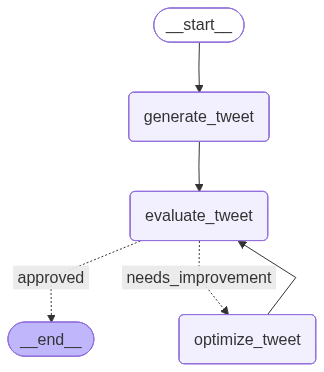

In [ ]:
#Build graph
graph = StateGraph(TweetState)

#Add nodes to graph
graph.add_node('generate_tweet', generate_tweet)
graph.add_node('evaluate_tweet', evaluate_tweet)
graph.add_node('optimize_tweet', optimize_tweet)

#Add edges to graph
graph.add_edge(START, 'generate_tweet')
graph.add_edge('generate_tweet', 'evaluate_tweet')

#If the nodes don't exist, then conditional will require JSON or dict as input for routing
graph.add_conditional_edges('evaluate_tweet', route_evaluation, {'approved': END, 'needs_improvement': 'optimize_tweet'})
graph.add_edge('optimize_tweet', 'evaluate_tweet')

#Compile graph
g = graph.compile()
g

In [ ]:
#Execute the graph

#Initial State
initial_state = {
    'topic': 'Job hunting in Lithuania',
    'iteration': 0,
    'max_iteration': 3
}

#Final State
final_state = g.invoke(initial_state)

#print state
print(final_state)

{'topic': 'Job hunting in Lithuania', 'tweet': '"Job hunting in Lithuania feels like playing hide and seek in a haunted house—just when you think you’ve found the exit, a ghost of disappointment pops out! Time to embrace the scares and DIY my career with a little more courage! 👻💼 #JobHunt #LithuaniaLife"', 'evaluation': 'approved', 'evaluator_feedback': "The tweet is original and uses a creative comparison between job hunting and a haunted house to capture attention. It introduces humor through the 'ghost of disappointment' and maintains a relatable tone for anyone familiar with job search struggles. The use of emojis adds a playful touch. While it may not elicit a strong laugh, it could resonate with others in similar situations, enhancing its virality potential. It avoids a setup-punchline structure, maintaining engagement and flow throughout. To enhance its punchiness, consider tightening the language slightly for even greater impact.", 'iteration': 4, 'max_iteration': 3, 'tweet_his

In [ ]:
print(final_state['tweet_history'])

['"Job hunting in Lithuania feels like playing hide and seek in a haunted house—just when you think you’ve found the exit, a ghost of disappointment pops out! Time to embrace the scares and DIY my career with a little more courage! 👻💼 #JobHunt #LithuaniaLife"']


In [ ]:
print(final_state['feedback_history'])

["The tweet is original and uses a creative comparison between job hunting and a haunted house to capture attention. It introduces humor through the 'ghost of disappointment' and maintains a relatable tone for anyone familiar with job search struggles. The use of emojis adds a playful touch. While it may not elicit a strong laugh, it could resonate with others in similar situations, enhancing its virality potential. It avoids a setup-punchline structure, maintaining engagement and flow throughout. To enhance its punchiness, consider tightening the language slightly for even greater impact."]
